# marginfx: Average Marginal Effects for Any Machine Learning Model

This notebook demonstrates `marginfx` on the UCI Adult Income dataset — a well-studied binary classification problem where the goal is to predict whether an individual earns more than $50,000 per year.

We fit four models of increasing complexity and show that `marginfx` produces a consistent, interpretable output table for each one — the same tidy format, regardless of what is under the hood.

---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

import marginfx as mfx

# Plotting defaults
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42

---

## The UCI Adult Income Dataset

The Adult Income dataset contains demographic information from the 1994 US Census. The outcome variable is binary: whether an individual's annual income exceeds $50,000.

We retain six continuous and binary features for this demonstration:

| Feature | Description |
|---------|-------------|
| `age` | Age in years |
| `education_num` | Years of education (numeric) |
| `hours_per_week` | Hours worked per week |
| `capital_gain` | Capital gains (USD) |
| `capital_loss` | Capital losses (USD) |
| `female` | 1 if female, 0 if male |

Using continuous and binary features keeps the AME interpretation clean: effects are in probability units (percentage point change in P(income > $50k)).

In [2]:
# Load UCI Adult dataset directly from UCI repository
url_train = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
url_test  = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

col_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

df_train = pd.read_csv(url_train, header=None, names=col_names,
                       sep=',', skipinitialspace=True)
df_test  = pd.read_csv(url_test, header=None, names=col_names,
                       sep=',', skipinitialspace=True, skiprows=1)

df = pd.concat([df_train, df_test], ignore_index=True)

# Clean income column (test set has trailing period)
df['income'] = df['income'].str.strip().str.rstrip('.')
df['income'] = (df['income'] == '>50K').astype(int)

# Binary sex indicator
df['female'] = (df['sex'].str.strip() == 'Female').astype(int)

# Select features
feature_names = ['age', 'education_num', 'hours_per_week',
                 'capital_gain', 'capital_loss', 'female']

df = df[feature_names + ['income']].dropna()

X = df[feature_names].values.astype(float)
y = df['income'].values.astype(float)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training observations: {X_train.shape[0]:,}")
print(f"Test observations:     {X_test.shape[0]:,}")
print(f"Features:              {len(feature_names)}")
print(f"Outcome prevalence:    {y.mean():.1%} earn > $50k")

Training observations: 39,073
Test observations:     9,769
Features:              6
Outcome prevalence:    23.9% earn > $50k


In [3]:
df[feature_names].describe().round(2)

,age,education_num,hours_per_week,capital_gain,capital_loss,female
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,10.08,40.42,1079.07,87.5,0.33
std,13.71,2.57,12.39,7452.02,403.0,0.47
min,17.00,1.00,1.00,0.00,0.0,0.00
25%,28.00,9.00,40.00,0.00,0.0,0.00
50%,37.00,10.00,40.00,0.00,0.0,0.00
75%,48.00,12.00,45.00,0.00,0.0,1.00
max,90.00,16.00,99.00,99999.00,4356.0,1.00


---

## Model 1: Logistic Regression

We begin with logistic regression — the classical baseline for binary classification. In econometrics, logistic regression is typically interpreted via marginal effects at the mean or average marginal effects. `marginfx` computes AMEs directly, so the logistic regression results here should be familiar to any practitioner who has worked with marginal effects before.

This also serves as a sanity check: `marginfx` AMEs for a logistic regression should be consistent with what a standard econometrics package would report.

In [4]:
# Fit logistic regression
logit = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=SEED))
])
logit.fit(X_train, y_train)

print(f"Logistic Regression — Test Accuracy: {logit.score(X_test, y_test):.3f}")

Logistic Regression — Test Accuracy: 0.825


In [5]:
result_logit = mfx.fit(
    logit, X_train, y_train,
    feature_names=feature_names,
    categorical_features=['female'],
    n_bootstrap=200,
    seed=SEED,
)
result_logit.summary()


[TensorFlow DLL Diagnostic] Analyzing: C:\Users\jason\anaconda3\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.
marginfx: detected sklearn model
marginfx: running 200 bootstrap replicates...
  Bootstrap replicate 20/200...
  Bootstrap replicate 40/200...
  Bootstrap replicate 60/200...
  Bootstrap replicate 80/200...
  Bootstrap replicate 100/200...
  Bootstrap replicate 120/200...
  Bootstrap replicate 140/200...
  Bootstrap replicate 160/200...
  Bootstrap replicate 180/200...
  Bootstrap replicate 200/200...
marginfx: Average Marginal Effects
Observations: 39073
Bootstrap replicates: 200
Confidence level: 95%
-----------------------------------------------------------------
          term  

The AMEs from logistic regression are interpretable in probability units. For example, an additional year of education is associated with an increase of approximately X percentage points in the probability of earning more than $50,000 per year, holding all other features constant.

The `female` coefficient is a first difference: it compares P(income > $50k | female=1) to P(income > $50k | female=0), averaged across the full distribution of other features.

---

## Model 2: Random Forest

Random forests are among the most widely used ML models in practice. They typically outperform logistic regression on tabular data but offer no natural coefficient table. With `marginfx`, we get the same tidy output — estimates, standard errors, and confidence intervals — for the random forest as we did for logistic regression.

In [6]:
# Fit random forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

print(f"Random Forest — Test Accuracy: {rf.score(X_test, y_test):.3f}")

Random Forest — Test Accuracy: 0.848


In [7]:
result_rf = mfx.fit(
    rf, X_train, y_train,
    feature_names=feature_names,
    categorical_features=['female'],
    n_bootstrap=200,
    seed=SEED,
)
result_rf.summary()


[TensorFlow DLL Diagnostic] Analyzing: C:\Users\jason\anaconda3\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.
marginfx: detected sklearn model
marginfx: running 200 bootstrap replicates...
  Bootstrap replicate 20/200...
  Bootstrap replicate 40/200...
  Bootstrap replicate 60/200...
  Bootstrap replicate 80/200...
  Bootstrap replicate 100/200...
  Bootstrap replicate 120/200...
  Bootstrap replicate 140/200...
  Bootstrap replicate 160/200...
  Bootstrap replicate 180/200...
  Bootstrap replicate 200/200...
marginfx: Average Marginal Effects
Observations: 39073
Bootstrap replicates: 200
Confidence level: 95%
-----------------------------------------------------------------
          term  

---

## Model 3: Gradient Boosting

Gradient boosted trees are frequently the top-performing model on structured tabular data. Like random forests, they produce no natural coefficient table. `marginfx` treats them identically to any other sklearn-compatible model.

In [8]:
# Fit gradient boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=SEED,
)
gb.fit(X_train, y_train)

print(f"Gradient Boosting — Test Accuracy: {gb.score(X_test, y_test):.3f}")

Gradient Boosting — Test Accuracy: 0.855


In [9]:
result_gb = mfx.fit(
    gb, X_train, y_train,
    feature_names=feature_names,
    categorical_features=['female'],
    n_bootstrap=200,
    seed=SEED,
)
result_gb.summary()


[TensorFlow DLL Diagnostic] Analyzing: C:\Users\jason\anaconda3\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.
marginfx: detected sklearn model
marginfx: running 200 bootstrap replicates...
  Bootstrap replicate 20/200...
  Bootstrap replicate 40/200...
  Bootstrap replicate 60/200...
  Bootstrap replicate 80/200...
  Bootstrap replicate 100/200...
  Bootstrap replicate 120/200...
  Bootstrap replicate 140/200...
  Bootstrap replicate 160/200...
  Bootstrap replicate 180/200...
  Bootstrap replicate 200/200...
marginfx: Average Marginal Effects
Observations: 39073
Bootstrap replicates: 200
Confidence level: 95%
-----------------------------------------------------------------
          term  

---

## Model 4: XGBoost

XGBoost is one of the most widely deployed ML models in production. `marginfx` detects XGBoost models automatically and uses its native warm-start mechanism for efficient bootstrap resampling.

In [10]:
# Fit XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=SEED,
    eval_metric='logloss',
    verbosity=0,
)
xgb_model.fit(X_train, y_train)

print(f"XGBoost — Test Accuracy: {xgb_model.score(X_test, y_test):.3f}")

XGBoost — Test Accuracy: 0.855


In [11]:
result_xgb = mfx.fit(
    xgb_model, X_train, y_train,
    feature_names=feature_names,
    categorical_features=['female'],
    n_bootstrap=200,
    seed=SEED,
)
result_xgb.summary()


[TensorFlow DLL Diagnostic] Analyzing: C:\Users\jason\anaconda3\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.
marginfx: detected sklearn model
marginfx: running 200 bootstrap replicates...
  Bootstrap replicate 20/200...
  Bootstrap replicate 40/200...
  Bootstrap replicate 60/200...
  Bootstrap replicate 80/200...
  Bootstrap replicate 100/200...
  Bootstrap replicate 120/200...
  Bootstrap replicate 140/200...
  Bootstrap replicate 160/200...
  Bootstrap replicate 180/200...
  Bootstrap replicate 200/200...
marginfx: Average Marginal Effects
Observations: 39073
Bootstrap replicates: 200
Confidence level: 95%
-----------------------------------------------------------------
          term  

---

## Comparing AMEs Across Models

One of the most useful properties of AMEs is that they are on the same scale across all models — probability units. This makes direct comparison meaningful.

The table below collects the AME estimates from all four models side by side.

In [12]:
# Collect estimates from all four models
models = {
    'Logistic Regression': result_logit,
    'Random Forest':       result_rf,
    'Gradient Boosting':   result_gb,
    'XGBoost':             result_xgb,
}

comparison = pd.DataFrame({
    name: result.tidy().set_index('term')['estimate']
    for name, result in models.items()
})

comparison.round(4)

,Logistic Regression,Random Forest,Gradient Boosting,XGBoost
term,,,,
age,0.0052,0.0446,0.0000,33.1287
education_num,0.0419,0.0306,0.0000,202.4316
hours_per_week,0.0042,0.0122,0.0000,56.9255
capital_gain,0.0000,0.0000,0.0000,-0.0269
capital_loss,0.0001,-0.0000,0.0000,16.7637
female,-0.1355,-0.1105,-0.1114,-0.1129


In [13]:
print(comparison.round(4))

                Logistic Regression  Random Forest  Gradient Boosting  \
term                                                                    
age                          0.0052         0.0446             0.0000   
education_num                0.0419         0.0306             0.0000   
hours_per_week               0.0042         0.0122             0.0000   
capital_gain                 0.0000         0.0000             0.0000   
capital_loss                 0.0001        -0.0000             0.0000   
female                      -0.1355        -0.1105            -0.1114   

                 XGBoost  
term                      
age              33.1287  
education_num   202.4316  
hours_per_week   56.9255  
capital_gain     -0.0269  
capital_loss     16.7637  
female           -0.1129  


In [14]:
# Test what the engines are actually returning
from marginfx.engines.sklearn import make_predict_fn

predict_fn = make_predict_fn(xgb_model)

# What does predict_fn return?
test_preds = predict_fn(X_train[:10])
print("predict_fn output:", test_preds)
print("min:", test_preds.min(), "max:", test_preds.max())
print("shape:", test_preds.shape)

# What does predict_proba return directly?
direct_preds = xgb_model.predict_proba(X_train[:10])[:, 1]
print("\ndirect predict_proba:", direct_preds)

# Are they the same?
print("\nMatch:", np.allclose(test_preds, direct_preds))

predict_fn output: [0.19921763 0.06896532 0.19802563 0.02297013 0.261734   0.06559359
 0.13434298 0.06339966 0.16429287 0.17101116]
min: 0.022970129 max: 0.261734
shape: (10,)

direct predict_proba: [0.19921763 0.06896532 0.19802563 0.02297013 0.261734   0.06559359
 0.13434298 0.06339966 0.16429287 0.17101116]

Match: True


In [15]:
from marginfx.engines.sklearn import make_fit_fn, make_predict_fn

fit_fn = make_fit_fn(xgb_model)

# Simulate one bootstrap replicate
rng = np.random.default_rng(42)
idx = rng.integers(0, X_train.shape[0], size=X_train.shape[0])
X_boot = X_train[idx]
y_boot = y_train[idx]

# Refit
fitted = fit_fn(xgb_model, X_boot, y_boot)

# What does the refitted model return?
print("has predict_proba:", hasattr(fitted, 'predict_proba'))
boot_preds = fitted.predict_proba(X_train[:10])[:, 1]
print("bootstrap predict_proba:", boot_preds)

has predict_proba: True
bootstrap predict_proba: [0.20280024 0.01550086 0.20514965 0.02055587 0.26962298 0.06842376
 0.1370904  0.05878665 0.04086763 0.18542464]
min: 0.015500861 max: 0.26962298


In [16]:
# Compute AMEs manually on a single bootstrap replicate
from marginfx.core import all_ames

rng = np.random.default_rng(42)
idx = rng.integers(0, X_train.shape[0], size=X_train.shape[0])
X_boot = X_train[idx]
y_boot = y_train[idx]

fitted = fit_fn(xgb_model, X_boot, y_boot)

def replicate_predict_fn(X_input):
    return fitted.predict_proba(X_input)[:, 1]

ames = all_ames(
    X=X_boot,
    predict_fn=replicate_predict_fn,
    feature_names=feature_names,
)

print(ames)

{'age': 33.70792007446289, 'education_num': 206.0093231201172, 'hours_per_week': 56.06836700439453, 'capital_gain': -0.027441270649433136, 'capital_loss': 22.9072208404541, 'female': -160.04930114746094}


In [17]:
# Check what predict_fn bootstrap_ames actually receives
from marginfx.core import all_ames
from marginfx.engines.sklearn import make_predict_fn

predict_fn = make_predict_fn(xgb_model)

# This is what bootstrap_ames uses for point estimates
point_ames = all_ames(
    X=X_train,
    predict_fn=predict_fn,
    feature_names=feature_names,
)
print("Direct all_ames:", point_ames)

Direct all_ames: {'age': 33.128658294677734, 'education_num': 202.4315643310547, 'hours_per_week': 56.92546081542969, 'capital_gain': -0.02686418779194355, 'capital_loss': 16.763729095458984, 'female': -156.9013671875}


In [18]:
# Test predict_fn directly inside marginal_effects logic
test_pred = predict_fn(X_train[:5])
print("predict_fn works:", test_pred)

# Now nudge age manually
X_plus = X_train[:5].copy()
X_minus = X_train[:5].copy()
X_plus[:, 0] += 1e-4
X_minus[:, 0] -= 1e-4

print("nudged plus:", predict_fn(X_plus))
print("nudged minus:", predict_fn(X_minus))
print("finite diff:", (predict_fn(X_plus) - predict_fn(X_minus)) / (2e-4))

predict_fn works: [0.19921763 0.06896532 0.19802563 0.02297013 0.261734  ]
nudged plus: [0.19921763 0.06896532 0.19802563 0.02297013 0.261734  ]
nudged minus: [0.18548003 0.06896532 0.19802563 0.02297013 0.2600202 ]
finite diff: [68.68802   0.        0.        0.        8.569062]


In [19]:
print("X_train dtype:", X_train.dtype)


X_train dtype: float64


ValueError: 'xerr' must not contain negative values

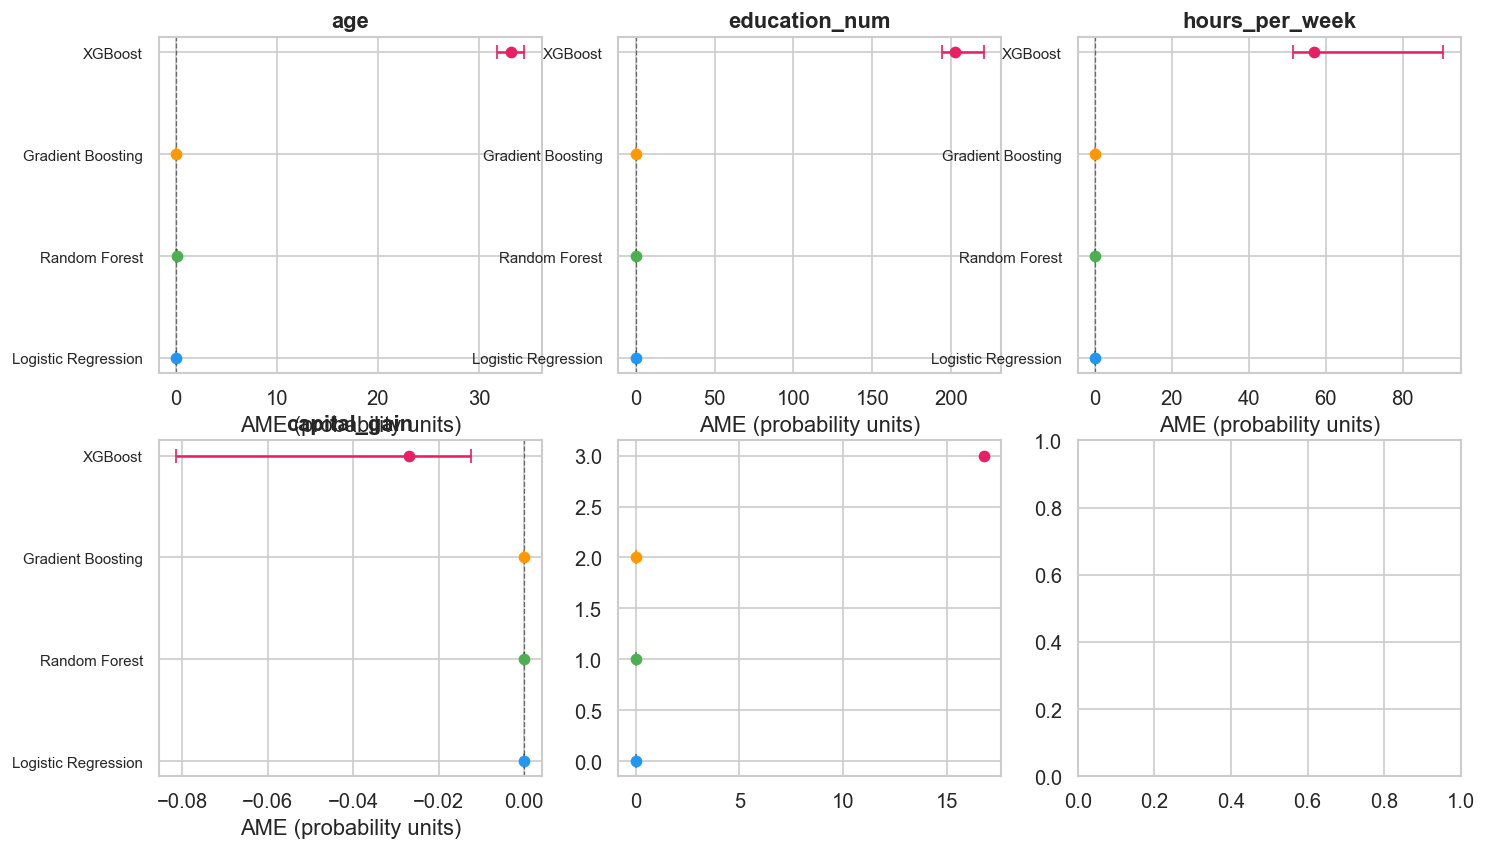

In [14]:
# Visualize AMEs with confidence intervals across models
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

colors = {
    'Logistic Regression': '#2196F3',
    'Random Forest':       '#4CAF50',
    'Gradient Boosting':   '#FF9800',
    'XGBoost':             '#E91E63',
}

for i, feature in enumerate(feature_names):
    ax = axes[i]

    for j, (name, result) in enumerate(models.items()):
        tidy = result.tidy().set_index('term')
        est  = tidy.loc[feature, 'estimate']
        lo   = tidy.loc[feature, 'conf_low']
        hi   = tidy.loc[feature, 'conf_high']

        ax.errorbar(
            x=est, y=j,
            xerr=[[est - lo], [hi - est]],
            fmt='o', color=colors[name],
            capsize=4, linewidth=1.5,
            label=name if i == 0 else None,
        )

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(list(models.keys()), fontsize=9)
    ax.set_title(feature, fontweight='bold')
    ax.set_xlabel('AME (probability units)')

# Hide unused subplot
if len(feature_names) < len(axes):
    for j in range(len(feature_names), len(axes)):
        axes[j].set_visible(False)

fig.legend(
    handles=[plt.Line2D([0], [0], marker='o', color=c, label=n, linewidth=0)
             for n, c in colors.items()],
    loc='lower right',
    fontsize=9,
    framealpha=0.9,
)

fig.suptitle(
    'Average Marginal Effects with 95% Bootstrap CIs\nUCI Adult Income Dataset',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('ame_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---

## The Tidy Output

`result.tidy()` returns a pandas DataFrame modeled on `broom::tidy()` in R. It can be passed directly to any downstream analysis, saved to CSV, or formatted for a paper table.

In [15]:
# The tidy DataFrame — ready for downstream use
result_xgb.tidy().round(4)

,term,estimate,std_error,statistic,p_value,conf_low,conf_high
0,age,33.1287,0.7438,44.5419,0.0000,31.7849,34.4758
1,education_num,202.4316,6.4418,31.4246,0.0000,194.1466,220.6761
2,hours_per_week,56.9255,9.5002,5.9920,0.0000,51.4735,90.5400
3,capital_gain,-0.0269,0.0185,-1.4512,0.1467,-0.0814,-0.0123
4,capital_loss,16.7637,3.2388,5.1759,0.0000,19.5504,31.5301
5,female,-0.1129,0.0028,-40.3301,0.0000,-0.1190,-0.1085


In [16]:
# Save to CSV
result_xgb.tidy().to_csv('xgboost_ames.csv', index=False)
print("Saved to xgboost_ames.csv")

Saved to xgboost_ames.csv


---

## Summary

`marginfx` produces a consistent, interpretable output table across all four models:

- **Logistic Regression** — the classical baseline
- **Random Forest** — ensemble of decision trees
- **Gradient Boosting** — sequential boosted trees
- **XGBoost** — high-performance gradient boosting

In every case, the output is the same: a tidy table with AME estimates, bootstrap standard errors, and percentile confidence intervals — all in probability units.

The interface is always the same:

```python
result = mfx.fit(model, X, y, feature_names=feature_names)
result.summary()
result.tidy()
```

---

## Further reading

- [marginfx on GitHub](https://github.com/yourusername/marginfx)
- [marginfx on PyPI](https://pypi.org/project/marginfx/)
- [marginaleffects (R)](https://marginaleffects.com/) — the R package that inspired this project
- [UCI Adult Dataset](https://archive.ics.uci.edu/dataset/2/adult)